In [2]:
pip install opencv-python pytesseract matplotlib numpy

In [3]:
!apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [6]:
!wget -O MobileNetSSD_deploy.prototxt "https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/voc/MobileNetSSD_deploy.prototxt"
!wget -O MobileNetSSD_deploy.caffemodel "https://github.com/PINTO0309/MobileNet-SSD-RealSense/raw/master/caffemodel/MobileNetSSD/MobileNetSSD_deploy.caffemodel"

--2026-06-25 17:45:34--  https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/voc/MobileNetSSD_deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29353 (29K) [text/plain]
Saving to: ‘MobileNetSSD_deploy.prototxt’

MobileNetSSD_deploy 100%[===================>]  28.67K  --.-KB/s    in 0.003s  

2026-06-25 17:45:34 (8.00 MB/s) - ‘MobileNetSSD_deploy.prototxt’ saved [29353/29353]

--2026-06-25 17:45:34--  https://github.com/PINTO0309/MobileNet-SSD-RealSense/raw/master/caffemodel/MobileNetSSD/MobileNetSSD_deploy.caffemodel
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/PIN


--- Initiating Object Detection on dog-puppy-on-garden-royalty-free-image-1586966191.avif ---
🎯 Detected: dog: 99.72%


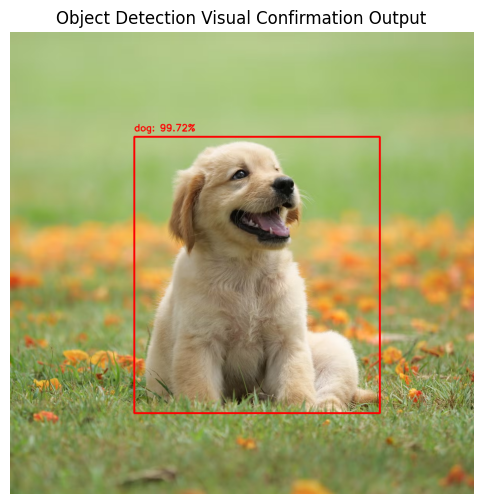

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def perform_object_detection(image_path):
    """Task B: Object Detection Pipeline using MobileNet-SSD"""
    print(f"\n--- Initiating Object Detection on {image_path} ---")

    CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
               "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
               "dog", "horse", "motorbike", "person", "pottedplant", "sheep",
               "sofa", "train", "tvmonitor"]

    try:
        # Loading the files you just downloaded
        net = cv2.dnn.readNetFromCaffe('MobileNetSSD_deploy.prototxt', 'MobileNetSSD_deploy.caffemodel')
    except Exception as e:
        print("❌ Error loading model files. Make sure the download step completed successfully.")
        return

    try:
        # Opening your puppy image safely using PIL
        pil_img = Image.open(image_path).convert('RGB')
        img = np.array(pil_img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    except Exception as e:
        print(f"❌ Error: Could not load image at '{image_path}'. Make sure it's uploaded to Colab.")
        return

    (h, w) = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        # 80% confidence target rule threshold from slide parameters
        if confidence > 0.80:
            idx = int(detections[0, 0, i, 1])
            label = f"{CLASSES[idx]}: {confidence * 100:.2f}%"
            print(f"🎯 Detected: {label}")

            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            # Draw target bounding boxes and label string
            cv2.rectangle(img, (startX, startY), (endX, endY), (0, 0, 255), 4)
            y = startY - 15 if startY - 15 > 15 else startY + 15
            cv2.putText(img, label, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # Render layout display
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Object Detection Visual Confirmation Output")
    plt.axis('off')
    plt.show()

# Run the execution line
perform_object_detection('dog-puppy-on-garden-royalty-free-image-1586966191.avif')